# Olympic Medals Analysis: Paris 2024 vs Tokyo 2020

A comparative analysis of Olympic medal standings across two consecutive Games.  
This notebook explores which countries improved, declined, or dominated both editions.

**Datasets:**
- `data/paris_2024_medals.csv` — Final medal table for the Paris 2024 Summer Olympics
- `data/tokyo_2020_medals.csv` — Final medal table for the Tokyo 2020 Summer Olympics (held 2021)

**Key questions:**
1. Which countries won the most medals across both Olympics combined?
2. Which countries improved the most from Tokyo to Paris?
3. How is global medal share distributed among the top nations?

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 2. Load Data

In [2]:
paris = pd.read_csv("data/paris_2024_medals.csv")
tokyo = pd.read_csv("data/tokyo_2020_medals.csv")

print(f"Paris 2024: {len(paris)} countries")
print(f"Tokyo 2020: {len(tokyo)} countries")

Paris 2024: 90 countries
Tokyo 2020: 88 countries


In [3]:
paris.head(5)

,Rank,Country,Country Code,Gold,Silver,Bronze,Total
0,1,United States,US,40,44,42,126
1,2,China,CHN,40,27,24,91
2,3,Japan,JPN,20,12,13,45
3,4,Australia,AUS,18,19,16,53
4,5,France,FRA,16,26,22,64


In [4]:
tokyo.head(5)

,Country,Gold Medal,Silver Medal,Bronze Medal,Total,Rank By Total
0,United States of America,39,41,33,113,1
1,People's Republic of China,38,32,18,88,2
2,ROC,20,28,23,71,3
3,Great Britain,22,21,22,65,4
4,Japan,27,14,17,58,5


## 3. Standardize Column Names

In [5]:
tokyo = tokyo.rename(columns={
    "Country":       "Country",
    "Gold Medal":    "Gold_Tokyo",
    "Silver Medal":  "Silver_Tokyo",
    "Bronze Medal":  "Bronze_Tokyo",
    "Total":         "Total_Tokyo",
    "Rank By Total": "Rank_Tokyo",
})

paris = paris.rename(columns={
    "Rank":         "Rank_Paris",
    "Country":      "Country",
    "Country Code": "Code",
    "Gold":         "Gold_Paris",
    "Silver":       "Silver_Paris",
    "Bronze":       "Bronze_Paris",
    "Total":        "Total_Paris",
})

## 4. Normalize Country Names

The two datasets use different spellings for some countries.  
A mapping dictionary unifies them before merging.

In [6]:
# Confirm which names differ between datasets
paris_countries = set(paris["Country"])
tokyo_countries = set(tokyo["Country"])

only_in_tokyo = tokyo_countries - paris_countries
only_in_paris = paris_countries - tokyo_countries

print("Only in Tokyo:", sorted(only_in_tokyo))
print("\nOnly in Paris:", sorted(only_in_paris))

Only in Tokyo: ['Burkina Faso', 'Estonia', 'Fiji', 'Ghana', 'Great Britain', 'Hong Kong, China', 'Islamic Republic of Iran', 'Ivory Coast', 'Kuwait', 'Pakistan', "People's Republic of China", 'Qatar', 'ROC', 'Republic of Korea', 'Republic of Moldova', 'San Marino', 'Syria', 'Turkmenistan', 'Uganda', 'United States of America', 'Zambia']

Only in Paris: ['Albania', 'Algeria', 'Austria', 'Botswana', 'Cape Verde', 'Chile', 'China', "Côte d'Ivoire", 'Dominica', 'Finland', 'Hong Kong', 'Iran', 'Lithuania', 'Mexico', 'Moldova', 'Namibia', 'Panama', 'Puerto Rico', 'Refugee Olympic Team', 'Slovakia', 'South Korea', 'St Lucia', 'United States']


In [7]:
name_mapping = {
    # Tokyo spellings -> unified name
    "People's Republic of China": "China",
    "United States of America":   "United States",
    "ROC":                        "Russia",   # Russian Olympic Committee
    "Republic of Korea":          "South Korea",
    "Islamic Republic of Iran":   "Iran",
    "Hong Kong, China":           "Hong Kong",
    "Ivory Coast":                "Côte d'Ivoire",
    "Republic of Moldova":        "Moldova",
}

tokyo["Country"] = tokyo["Country"].replace(name_mapping)
paris["Country"] = paris["Country"].replace(name_mapping)

## 5. Merge and Clean

In [8]:
df = pd.merge(tokyo, paris, on="Country", how="outer")

# Fill missing values with 0 (country did not participate or win medals)
medal_cols = ["Gold_Tokyo", "Silver_Tokyo", "Bronze_Tokyo", "Total_Tokyo",
              "Gold_Paris", "Silver_Paris", "Bronze_Paris", "Total_Paris"]
df[medal_cols] = df[medal_cols].fillna(0).astype(int)

# Reorder columns for readability
front_cols = ["Country", "Code"]
rest_cols  = [c for c in df.columns if c not in front_cols]
df = df[front_cols + rest_cols]

df["Total_Combined"] = df["Total_Tokyo"] + df["Total_Paris"]
df = df.sort_values("Total_Combined", ascending=False).reset_index(drop=True)

print(f"Merged dataset: {len(df)} countries")
df.head(10)

Merged dataset: 104 countries


,Country,Code,Gold_Tokyo,Silver_Tokyo,Bronze_Tokyo,Total_Tokyo,Rank_Tokyo,Rank_Paris,Gold_Paris,Silver_Paris,Bronze_Paris,Total_Paris,Total_Combined
0,United States,US,39,41,33,113,1.0,1.0,40,44,42,126,239
1,China,CHN,38,32,18,88,2.0,2.0,40,27,24,91,179
2,Japan,JPN,27,14,17,58,5.0,3.0,20,12,13,45,103
3,Australia,AUS,17,7,22,46,6.0,4.0,18,19,16,53,99
4,France,FRA,10,12,11,33,10.0,5.0,16,26,22,64,97
5,Italy,ITA,10,10,20,40,7.0,8.0,12,13,15,40,80
6,Russia,NaN,20,28,23,71,3.0,NaN,0,0,0,0,71
7,Netherlands,NED,10,12,14,36,9.0,6.0,15,7,12,34,70
8,Germany,GER,10,11,16,37,8.0,9.0,12,13,8,33,70
9,Great Britain,NaN,22,21,22,65,4.0,NaN,0,0,0,0,65


## 6. Analysis 1 — Top 10 Countries by Combined Medals

A stacked bar chart breaks total medals into Tokyo and Paris contributions.

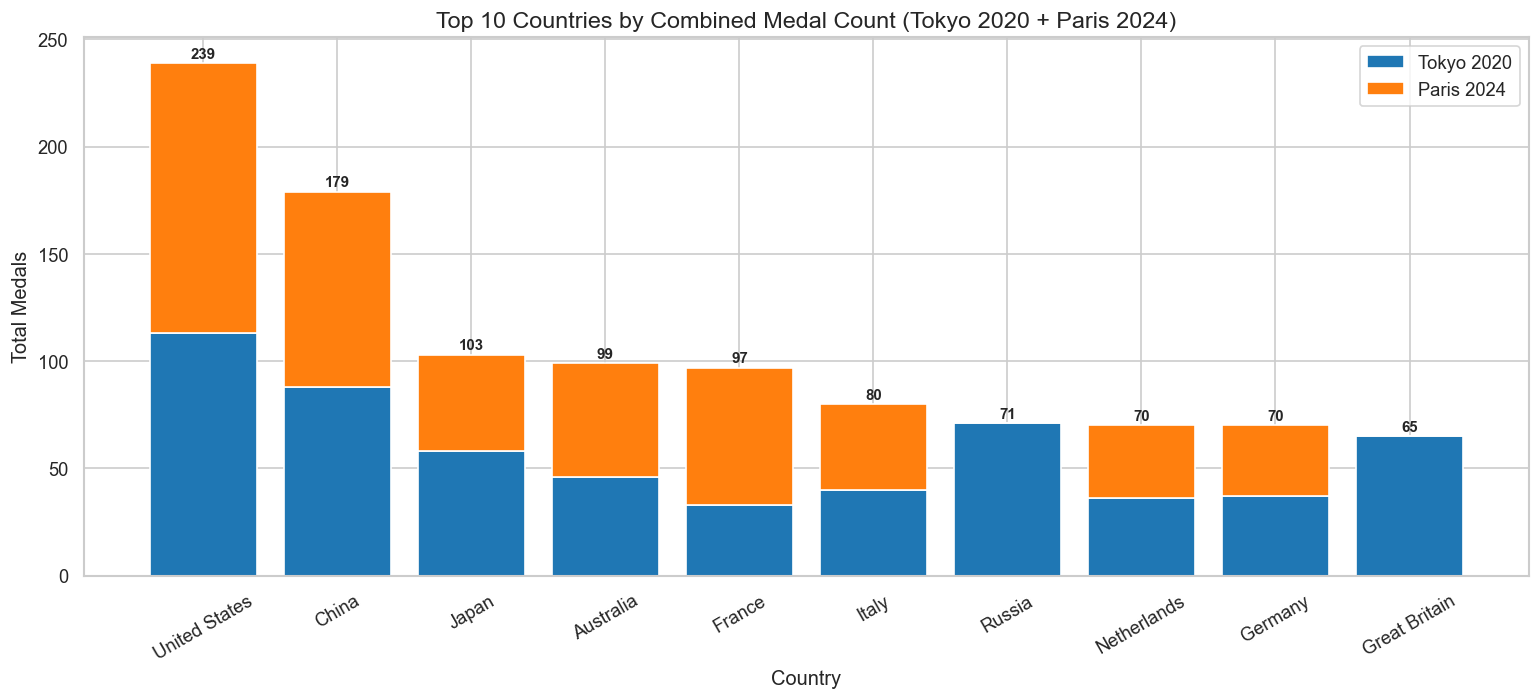

In [9]:
top10 = df.nlargest(10, "Total_Combined")

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(top10["Country"], top10["Total_Tokyo"], label="Tokyo 2020", color="#1f77b4")
ax.bar(top10["Country"], top10["Total_Paris"],
       bottom=top10["Total_Tokyo"], label="Paris 2024", color="#ff7f0e")

for i, row in top10.reset_index(drop=True).iterrows():
    ax.text(i, row["Total_Combined"] + 1, str(row["Total_Combined"]),
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("Country", fontsize=12)
ax.set_ylabel("Total Medals", fontsize=12)
ax.set_title("Top 10 Countries by Combined Medal Count (Tokyo 2020 + Paris 2024)", fontsize=14)
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 7. Analysis 2 — Medal Trajectory (Paris vs Tokyo)

Trajectory = Total_Paris − Total_Tokyo.  
A positive value means the country won more medals in Paris; negative means fewer.  
Russia (ROC) is excluded because it did not compete under its own flag in Paris 2024.

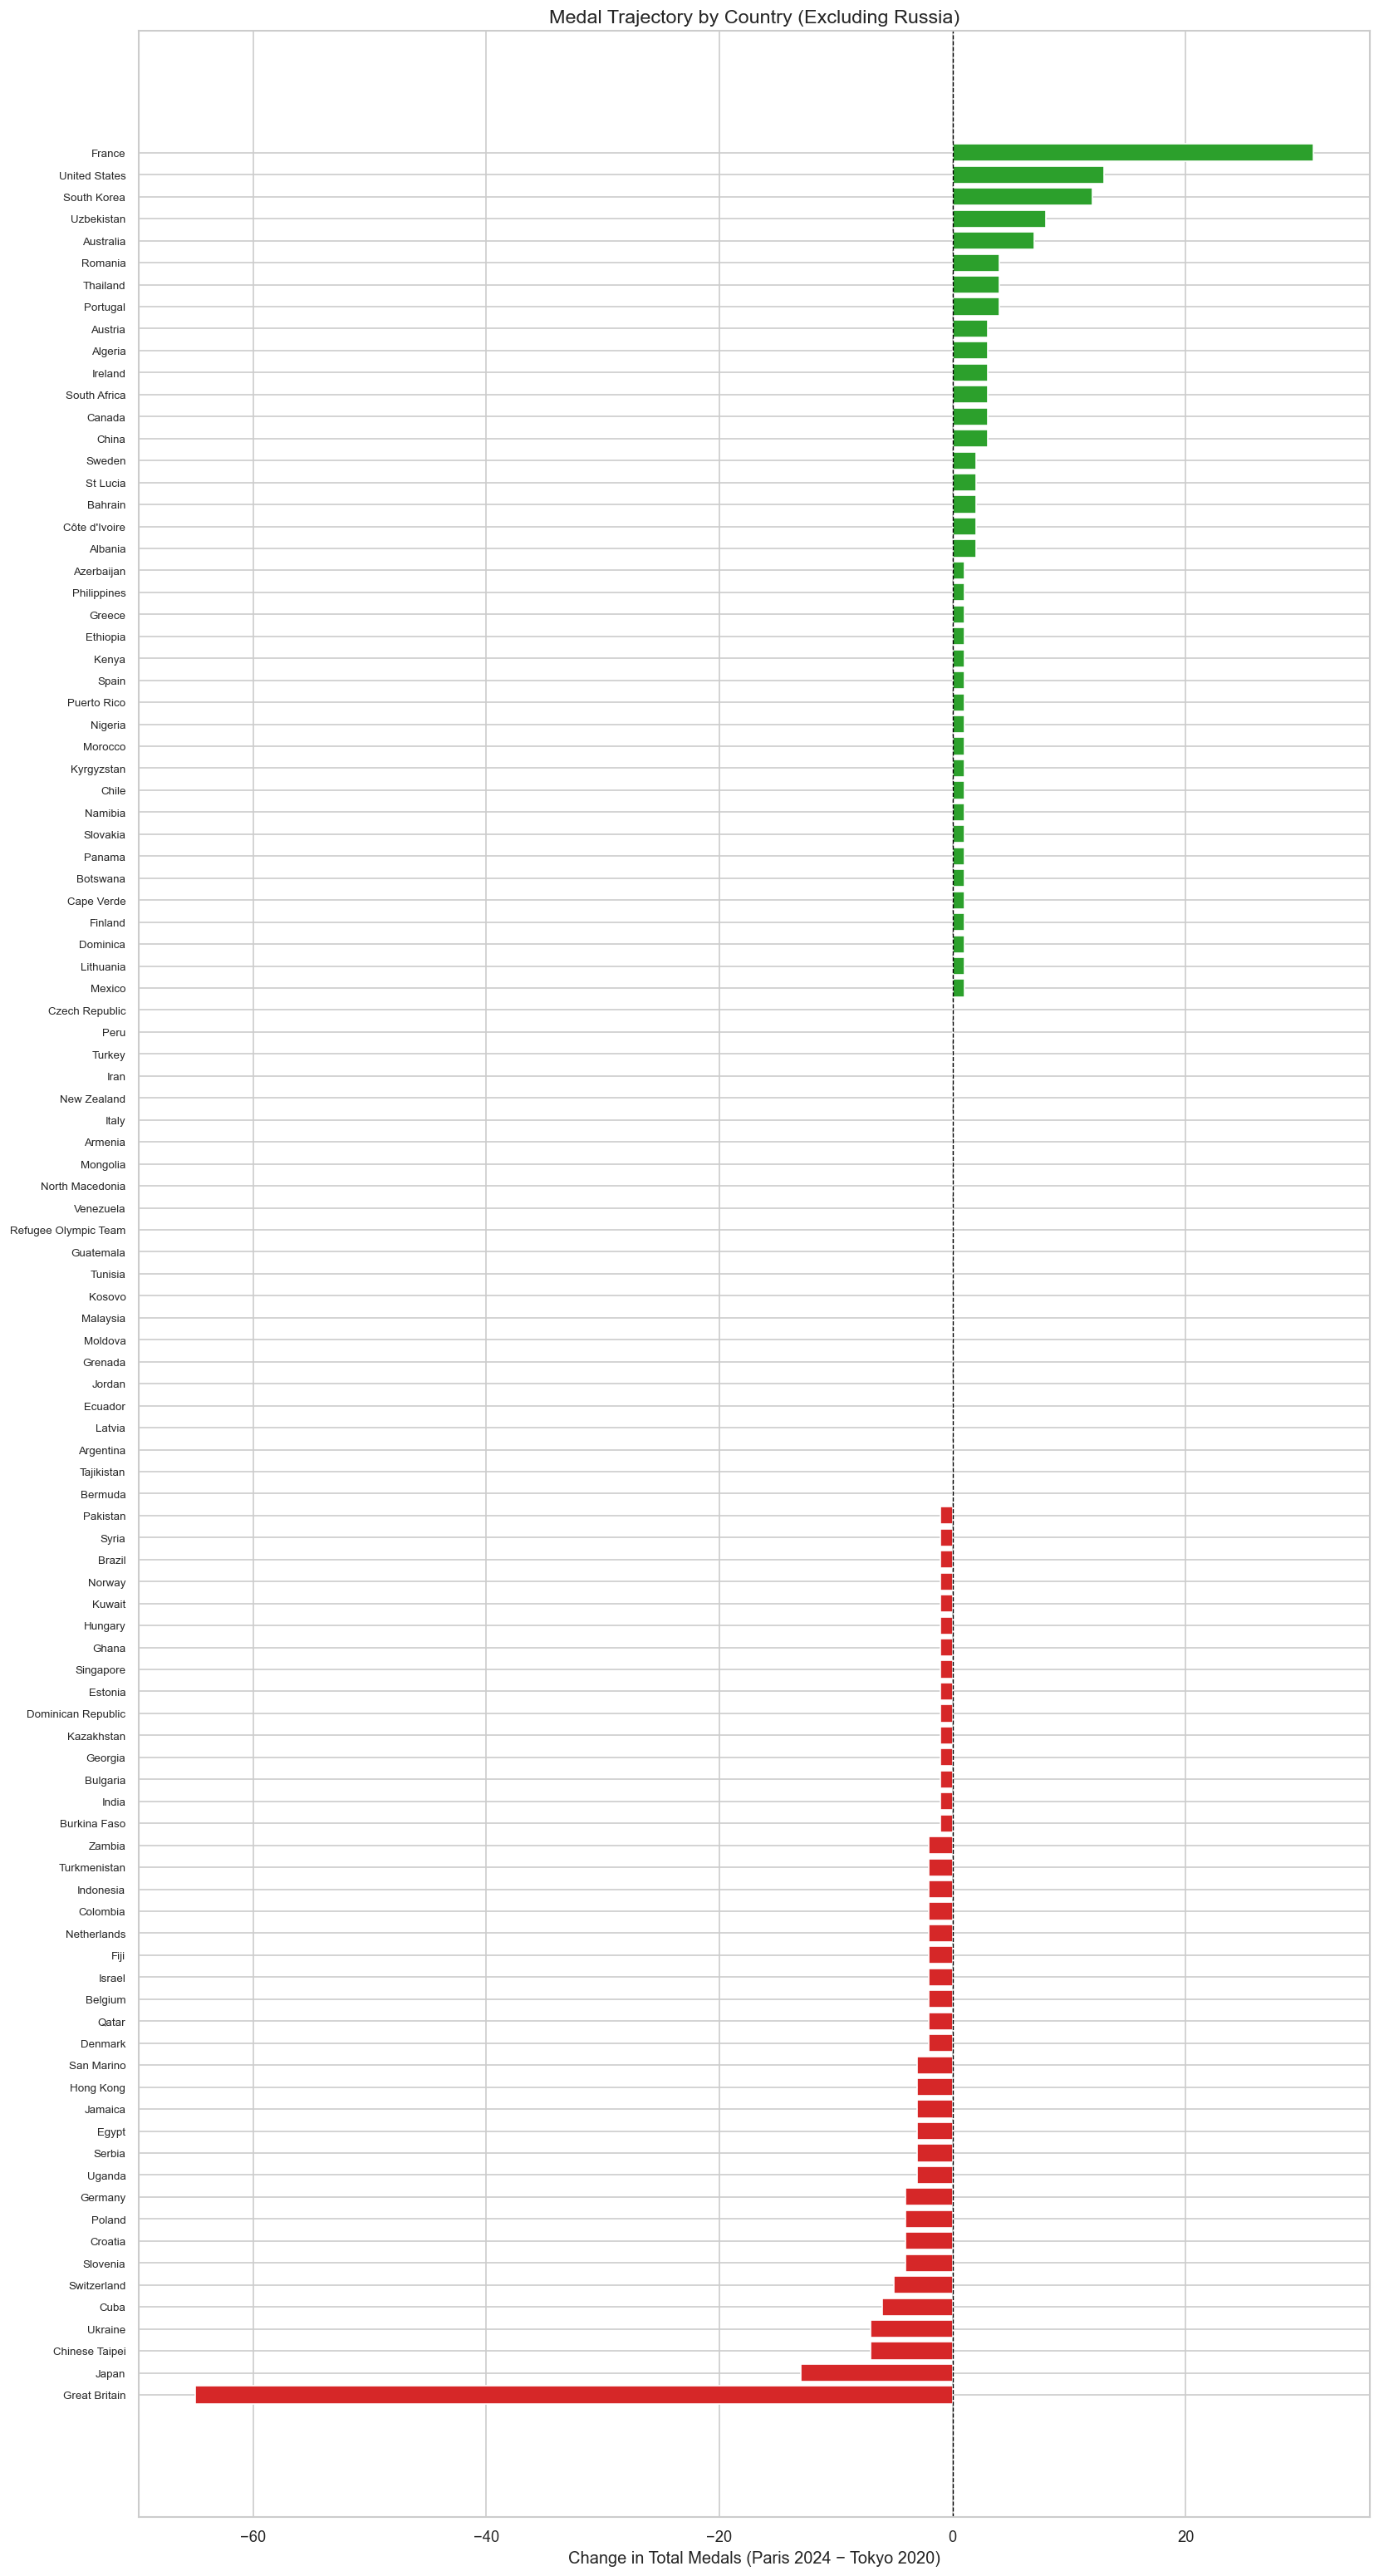

In [10]:
df_traj = df[df["Country"] != "Russia"].copy()
df_traj["Trajectory"] = df_traj["Total_Paris"] - df_traj["Total_Tokyo"]
df_traj = df_traj.sort_values("Trajectory")

colors = ["#2ca02c" if v > 0 else "#d62728" for v in df_traj["Trajectory"]]

fig, ax = plt.subplots(figsize=(14, 26))
ax.barh(df_traj["Country"], df_traj["Trajectory"], color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Change in Total Medals (Paris 2024 − Tokyo 2020)", fontsize=12)
ax.set_title("Medal Trajectory by Country (Excluding Russia)", fontsize=14)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

## 8. Analysis 3 — Top 5 Risers and Fallers

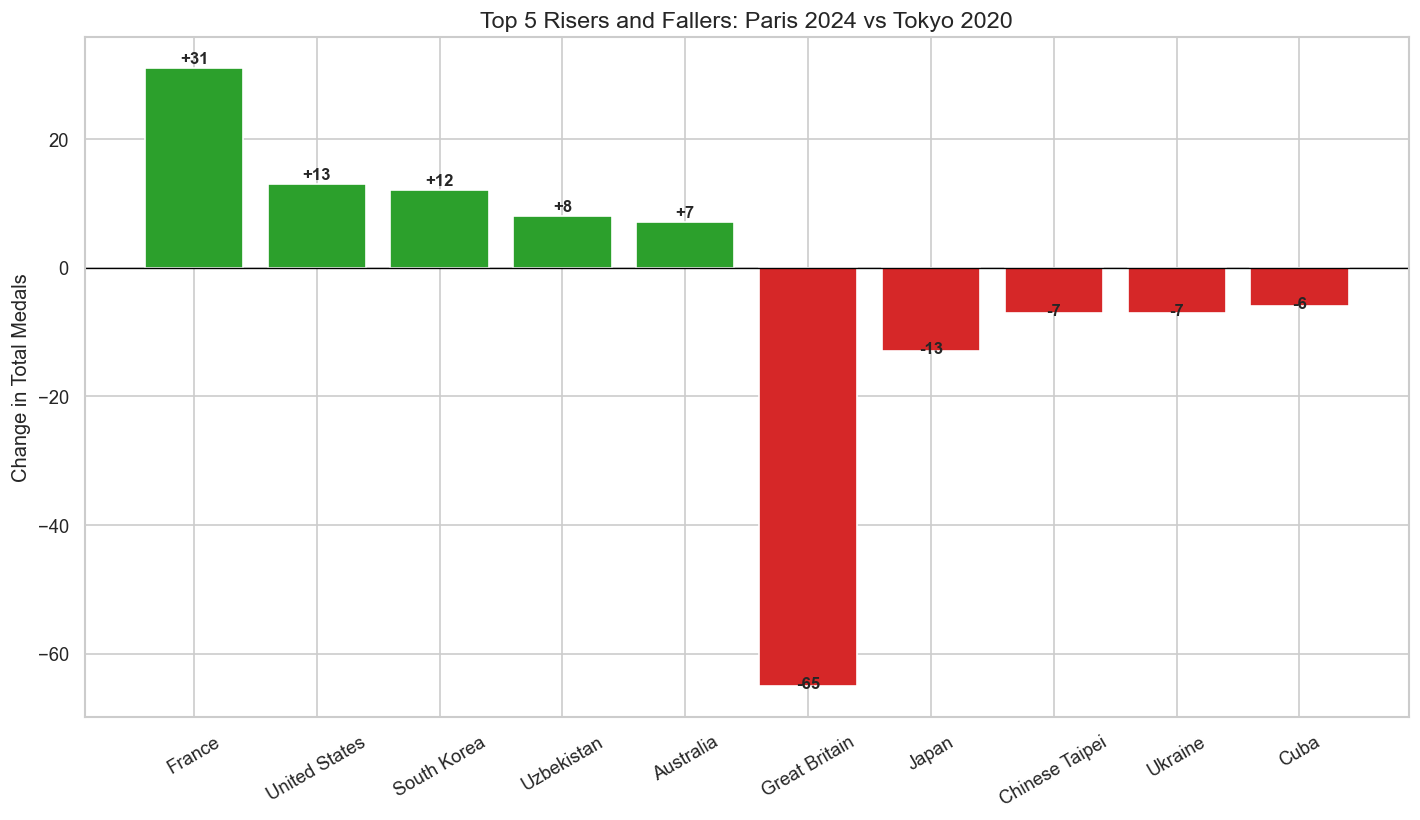

In [11]:
top5_up   = df_traj.nlargest(5, "Trajectory")
top5_down = df_traj.nsmallest(5, "Trajectory")
top5_both = pd.concat([top5_up, top5_down])

colors_both = ["#2ca02c" if v > 0 else "#d62728" for v in top5_both["Trajectory"]]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(top5_both["Country"], top5_both["Trajectory"], color=colors_both)

for bar, val in zip(bars, top5_both["Trajectory"]):
    offset = 0.3 if val >= 0 else -0.8
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + offset,
            f"{val:+d}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Change in Total Medals", fontsize=12)
ax.set_title("Top 5 Risers and Fallers: Paris 2024 vs Tokyo 2020", fontsize=14)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 9. Analysis 4 — Gold Medal Breakdown: Top 15 Countries

Grouped bars comparing gold medals won in each edition.

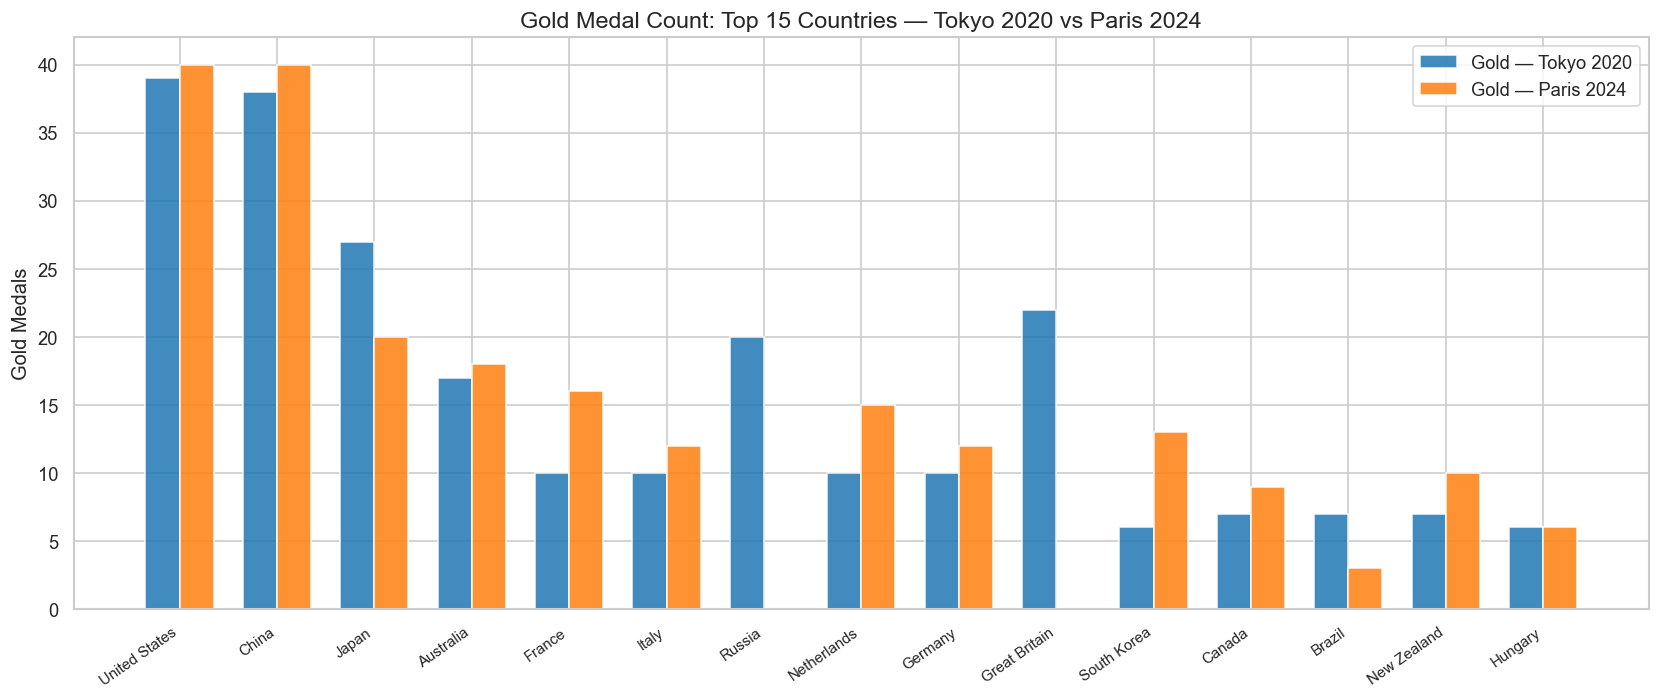

In [12]:
import numpy as np

top15 = df.nlargest(15, "Total_Combined").reset_index(drop=True)
x = np.arange(len(top15))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width / 2, top15["Gold_Tokyo"], width, label="Gold — Tokyo 2020",
       color="#1f77b4", alpha=0.85)
ax.bar(x + width / 2, top15["Gold_Paris"],  width, label="Gold — Paris 2024",
       color="#ff7f0e", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top15["Country"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Gold Medals", fontsize=12)
ax.set_title("Gold Medal Count: Top 15 Countries — Tokyo 2020 vs Paris 2024", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 10. Analysis 5 — Global Medal Share (Paris 2024)

Pie chart showing how medals are distributed among the top 20 countries versus the rest of the world.

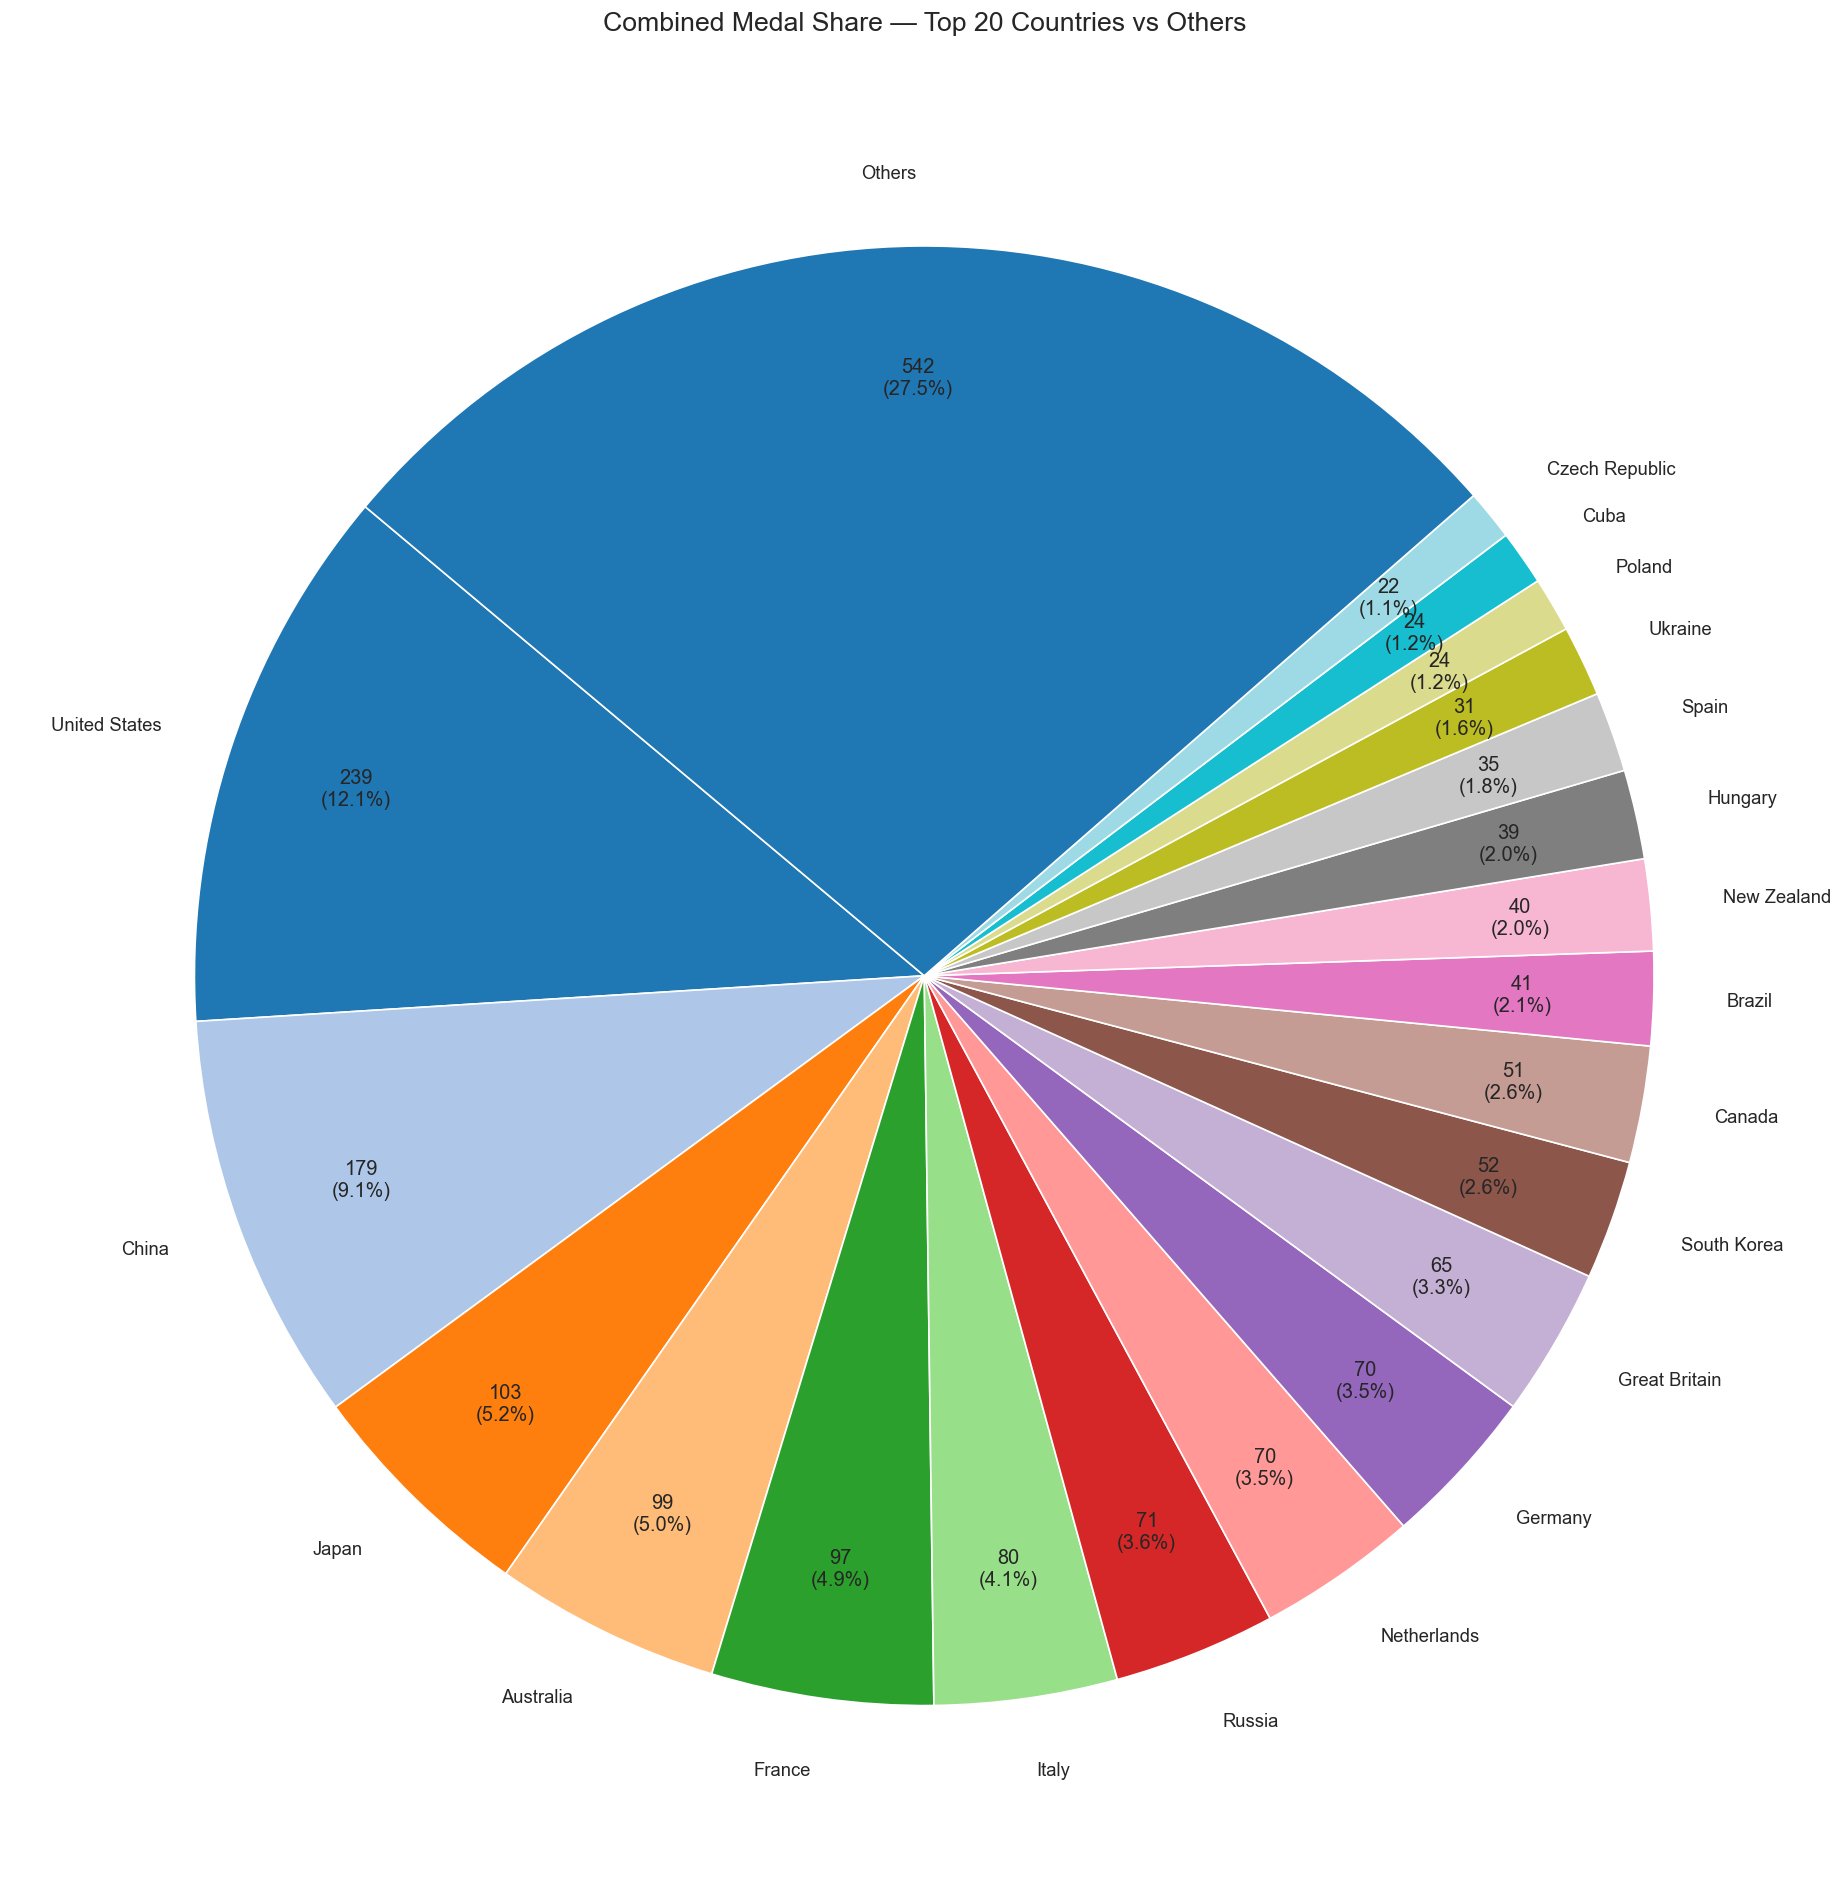

In [13]:
top20 = df.nlargest(20, "Total_Combined")
others = df["Total_Combined"].sum() - top20["Total_Combined"].sum()

labels = top20["Country"].tolist() + ["Others"]
sizes  = top20["Total_Combined"].tolist() + [others]
colors = sns.color_palette("tab20", n_colors=21)

def fmt_pct(pct, all_vals):
    count = int(round(pct / 100 * sum(all_vals)))
    return f"{count}\n({pct:.1f}%)"

fig, ax = plt.subplots(figsize=(16, 16))
ax.pie(
    sizes,
    labels=labels,
    autopct=lambda p: fmt_pct(p, sizes),
    colors=colors,
    startangle=140,
    pctdistance=0.82,
)
ax.set_title("Combined Medal Share — Top 20 Countries vs Others", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## 11. Summary Table

Quick look at the top 20 countries with key stats.

In [14]:
summary = df[["Country", "Gold_Tokyo", "Total_Tokyo",
              "Gold_Paris", "Total_Paris", "Total_Combined"]].head(20).copy()

# Add trajectory only for non-Russia rows
summary["Trajectory"] = summary["Total_Paris"] - summary["Total_Tokyo"]
summary["Trajectory"] = summary["Trajectory"].apply(lambda x: f"+{x}" if x > 0 else str(x))

summary.style \
    .set_caption("Top 20 Countries — Combined Medal Summary") \
    .background_gradient(subset=["Total_Combined"], cmap="YlOrRd") \
    .set_properties(**{"text-align": "center"})

,Country,Gold_Tokyo,Total_Tokyo,Gold_Paris,Total_Paris,Total_Combined,Trajectory
0,United States,39,113,40,126,239,+13
1,China,38,88,40,91,179,+3
2,Japan,27,58,20,45,103,-13
3,Australia,17,46,18,53,99,+7
4,France,10,33,16,64,97,+31
5,Italy,10,40,12,40,80,0
6,Russia,20,71,0,0,71,-71
7,Netherlands,10,36,15,34,70,-2
8,Germany,10,37,12,33,70,-4
9,Great Britain,22,65,0,0,65,-65
